## q1 a

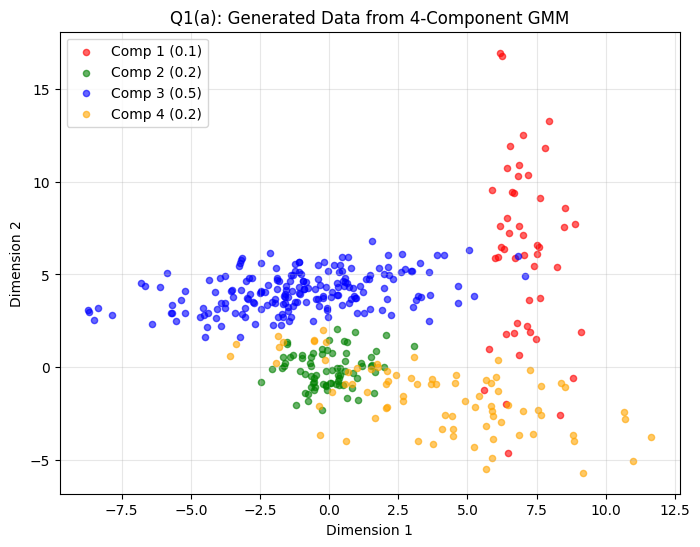

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# set random seed (Fixed syntax error from template)
np.random.seed(42)

# define mixture model parameters
weights = np.array([0.1, 0.2, 0.5, 0.2])
means = [
    np.array([7, 6]),
    np.array([0, 0]),
    np.array([-1, 4]),
    np.array([5, -2])
]
covs = [
    np.array([[1, 0], [0, 25]]),
    np.array([[1, 0], [0, 1]]),
    np.array([[9, 1], [1, 1]]),
    np.array([[16, -6], [-6, 4]])
]

# generate 400 random points from the mixture model
N = 400
# Step 1: Determine which component each point belongs to
# We sample the latent variable z ~ Categorical(weights)
z_labels = np.random.choice(len(weights), size=N, p=weights)

X_data = []
true_labels = []

# Step 2: Sample from the specific Gaussian for each component
for i in range(4):
    # Count how many points belong to component i
    n_i = np.sum(z_labels == i)
    if n_i > 0:
        # Sample n_i points from N(mu_i, Sigma_i)
        pts = np.random.multivariate_normal(means[i], covs[i], n_i)
        X_data.append(pts)
        true_labels.append(np.full(n_i, i))

# Stack arrays for plotting and future use
X = np.vstack(X_data)
y = np.concatenate(true_labels)

# plot points, using colors to distinguish each of the components
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue', 'orange']
labels = ['Comp 1 (0.1)', 'Comp 2 (0.2)', 'Comp 3 (0.5)', 'Comp 4 (0.2)']

for i in range(4):
    plt.scatter(X[y == i, 0], X[y == i, 1], 
                c=colors[i], label=labels[i], alpha=0.6, s=20)

plt.title('Q1(a): Generated Data from 4-Component GMM')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('q1a.png') # Save for LaTeX inclusion
plt.show()

## q1 b

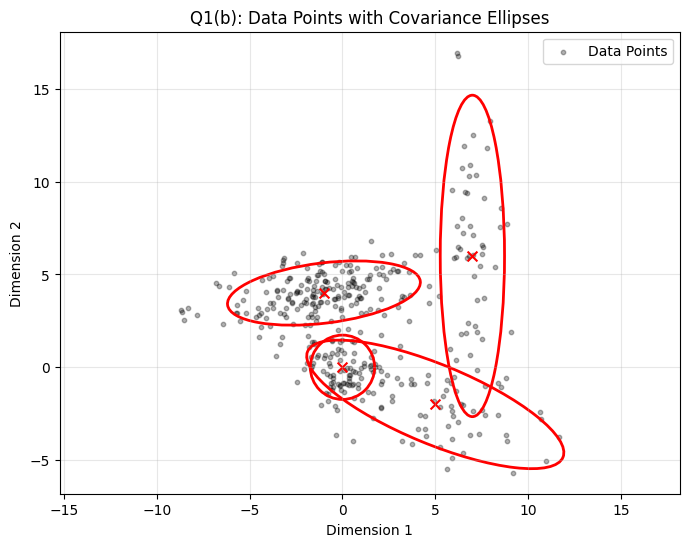

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# --- REPRODUCE DATA FROM 1(a) ---
np.random.seed(42)
weights = np.array([0.1, 0.2, 0.5, 0.2])
means = [np.array([7, 6]), np.array([0, 0]), 
         np.array([-1, 4]), np.array([5, -2])]
covs = [np.array([[1, 0], [0, 25]]), np.array([[1, 0], [0, 1]]), 
        np.array([[9, 1], [1, 1]]), np.array([[16, -6], [-6, 4]])]

# Generate Data
X_list = []
z_labels = np.random.choice(len(weights), size=400, p=weights)
for i in range(4):
    n_i = np.sum(z_labels == i)
    if n_i > 0:
        X_list.append(np.random.multivariate_normal(means[i], covs[i], n_i))
X = np.vstack(X_list)

# --- SOLUTION 1(b) ROUTINE ---

def plot_ellipse(mu, sigma, ax):
    """
    Plots an ellipse representing the covariance matrix sigma 
    centered at mu.
    """
    # Eigendecomposition
    vals, vecs = np.linalg.eigh(sigma)
    
    # Sort eigenvalues/vectors to ensure consistent angle calculation
    # (Largest eigenvalue first)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    
    # Calculate Angle (in degrees)
    # arctan2(y, x) of the first eigenvector
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    
    # Width and Height based on eigenvalues
    # Using the scaling factor from the template: 2 * sqrt(3 * lambda)
    width, height = 2.0 * np.sqrt(3.0 * vals)
    
    # Create Ellipse Patch
    ell = Ellipse(xy=mu, width=width, height=height, angle=theta, 
                  edgecolor='red', facecolor='none', lw=2, label='_nolegend_')
    ax.add_artist(ell)

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Plot all data points in the same color (e.g., black/gray)
ax.scatter(X[:, 0], X[:, 1], c='k', s=10, alpha=0.3, label='Data Points')

# 2. Plot ellipses for each component
for i in range(4):
    plot_ellipse(means[i], covs[i], ax)
    # Optional: Mark the center
    ax.scatter(means[i][0], means[i][1], c='red', marker='x', s=50)

plt.title('Q1(b): Data Points with Covariance Ellipses')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal') # Important to see true shape of ellipses
plt.savefig('q1b.png')
plt.show()

## q1 c
`montage q1a.png q1b.png -geometry +5+5 -tile 1x2  q1c.png`


## q1 d

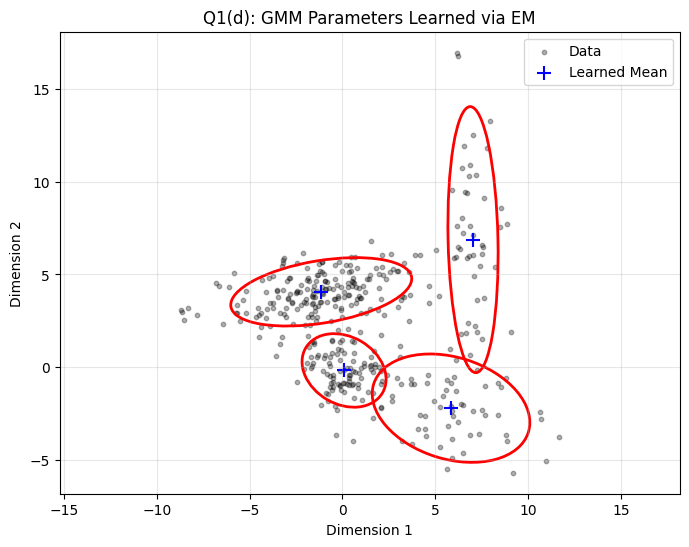

Learned Means:
 [[-1.14431475  4.06533763]
 [ 0.08562614 -0.17050355]
 [ 7.03352207  6.87777662]
 [ 5.84839771 -2.20299718]]
Learned Weights:
 [0.48275066 0.25898871 0.11446549 0.14379514]


In [3]:
from sklearn.mixture import GaussianMixture

# 1. Initialize and Fit the GMM
# n_components=4 matches our true K
# covariance_type='full' allows for arbitrary shapes (not just spherical)
# random_state=42 ensures the initialization is deterministic
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm.fit(X) # X is the (400, 2) array from part (a)

# 2. Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the original data
ax.scatter(X[:, 0], X[:, 1], c='k', s=10, alpha=0.3, label='Data')

# Plot the Learned Ellipses
# We iterate through the parameters found by the EM algorithm
for i in range(4):
    learned_mean = gmm.means_[i]
    learned_cov = gmm.covariances_[i]
    
    # Use the helper function defined in 1(b)
    plot_ellipse(learned_mean, learned_cov, ax)
    
    # Mark the learned centers
    ax.scatter(learned_mean[0], learned_mean[1], c='blue', marker='+', s=100, label='Learned Mean' if i==0 else "")

plt.title('Q1(d): GMM Parameters Learned via EM')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('q1d.png')
plt.show()

# Optional: Print parameters to compare numerically
print("Learned Means:\n", gmm.means_)
print("Learned Weights:\n", gmm.weights_)

## q1 e

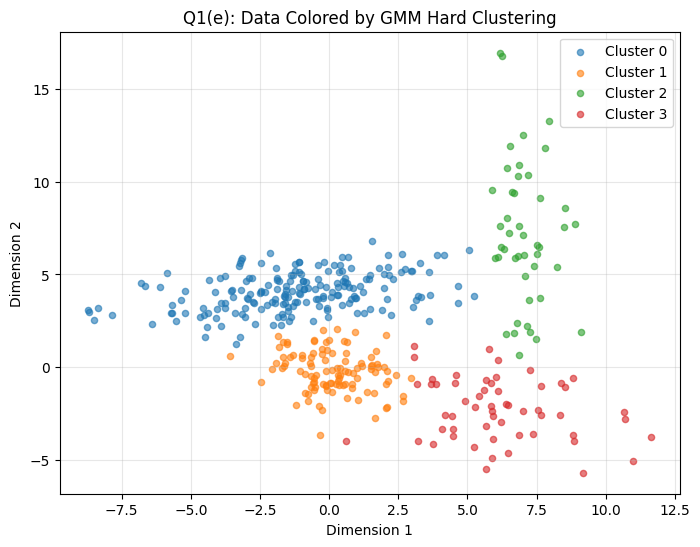

In [4]:
from sklearn.mixture import GaussianMixture

# 1. Fit the Model (Same as 1d)
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm.fit(X)

# 2. Predict the "Most Likely" component for each point (Hard Clustering)
# This assigns each point to the component with the highest posterior probability
y_pred = gmm.predict(X)

# 3. Plotting
plt.figure(figsize=(8, 6))

# Define colors for the PREDICTED clusters
# Note: These colors might not match the original indices 1-to-1 due to label switching
colors_pred = ['purple', 'cyan', 'lime', 'magenta'] 
for k in range(4):
    # Select points predicted to belong to cluster k
    mask = (y_pred == k)
    plt.scatter(X[mask, 0], X[mask, 1], s=20, label=f'Cluster {k}', alpha=0.6)

plt.title('Q1(e): Data Colored by GMM Hard Clustering')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('q1e.png')
plt.show()

## q1 f

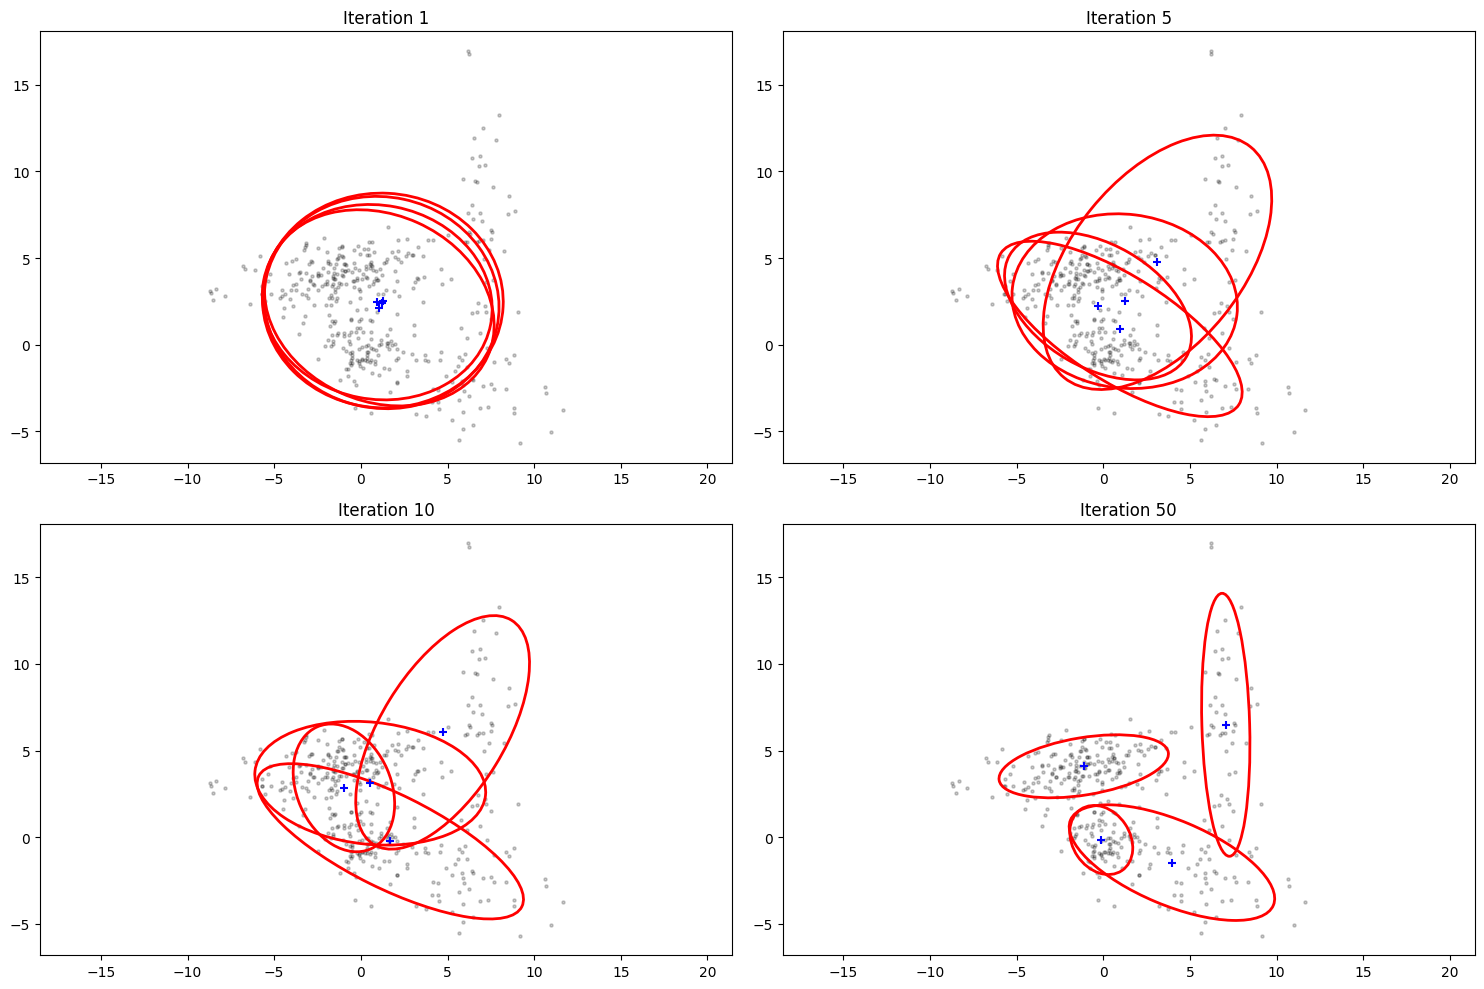

In [5]:
from sklearn.mixture import GaussianMixture

# Define the iteration snapshots we want to capture
# We use 'random' initialization to make the convergence process visible.
# (Default 'k-means' init is often too fast to see the progression)
iterations = [1, 5, 10, 50] 

plt.figure(figsize=(15, 10))

for idx, n_iter in enumerate(iterations):
    # Initialize GMM with specific max_iter
    # init_params='random' ensures we start from a raw state to see evolution
    gmm = GaussianMixture(n_components=4, 
                          covariance_type='full', 
                          max_iter=n_iter, 
                          random_state=42,
                          init_params='random')
    
    # Suppress convergence warnings for low iteration counts
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        gmm.fit(X)
    
    # Plotting subplot
    ax = plt.subplot(2, 2, idx+1)
    ax.scatter(X[:, 0], X[:, 1], c='k', s=5, alpha=0.2)
    
    # Plot learned ellipses
    for i in range(4):
        plot_ellipse(gmm.means_[i], gmm.covariances_[i], ax)
        ax.scatter(gmm.means_[i][0], gmm.means_[i][1], c='blue', marker='+')
        
    ax.set_title(f'Iteration {n_iter}')
    ax.axis('equal')

plt.tight_layout()
plt.savefig('/home/scotty/dsc_257/fall_25/module_09/hw/q1f_evolution.png')
plt.show()